# Lab 3 - Intuición estadística 

En este notebook se implementan las tareas del Lab 3: generación de dos distribuciones normales, visualización de sus pdf, derivación de la frontera analítica que las separa, generación de muestras (rvs), construcción de DataFrame de entrenamiento y test, ajuste de clasificadores y evaluación.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import learning_curve
sns.set_theme(style='whitegrid')

## 1) Construir dos distribuciones normales


## 2) Graficar las distribuciones

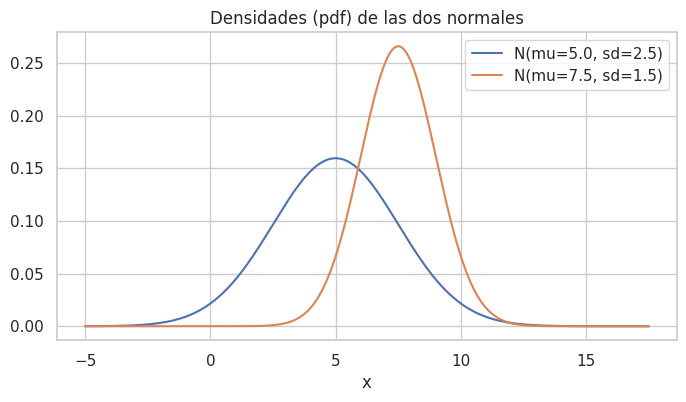

In [17]:
# parámetros
mu1, sigma1 = 5.0, 2.5
mu2, sigma2 = 7.5, 1.5
x = np.linspace(min(mu1, mu2)-4*max(sigma1, sigma2), max(mu1, mu2)+4*max(sigma1, sigma2), 1000)
pdf1 = stats.norm(loc=mu1, scale=sigma1).pdf(x)
pdf2 = stats.norm(loc=mu2, scale=sigma2).pdf(x)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf1, label=f'N(mu={mu1}, sd={sigma1})')
plt.plot(x, pdf2, label=f'N(mu={mu2}, sd={sigma2})')
plt.title('Densidades (pdf) de las dos normales')
plt.xlabel('x')
plt.legend()
plt.show()

## 2) Frontera analítica (resolver pdf1(x)=pdf2(x))
Cuando dos normales no tienen la misma desviación, la igualdad de pdf conduce a una ecuación cuadrática en `x`. Aquí calculamos la(s) solución(es) analíticas.

In [18]:

# Igualando y tomando logaritmo se obtiene una ecuación cuadrática en x:
a = 1/(2*sigma1**2) - 1/(2*sigma2**2)
b = -mu1/(sigma1**2) + mu2/(sigma2**2)
c = (mu1**2)/(2*sigma1**2) - (mu2**2)/(2*sigma2**2) - np.log(sigma2/sigma1)
roots = np.roots([a, b, c])
roots

array([11.9203679,  5.8921321])

## Ramdom variates (rvs)

In [19]:
# 3) generar muestras de entrenamiento
n_train = 100
rng = np.random.default_rng(42)
samples1 = stats.norm(loc=mu1, scale=sigma1).rvs(size=n_train, random_state=42)
samples2 = stats.norm(loc=mu2, scale=sigma2).rvs(size=n_train, random_state=24)

# etiquetas: 0 para distribución1, 1 para distribución2
X = np.concatenate([samples1, samples2])[:, None]  # columna X
Y = np.concatenate([np.zeros(len(samples1)), np.ones(len(samples2))])

df_train = pd.DataFrame({'X': X.ravel(), 'Y': Y.astype(int)})
df_train.head()

,X,Y
0,6.241785,0
1,4.654339,0
2,6.619221,0
3,8.807575,0
4,4.414617,0


## 4) gráfica superpuesta de muestras y densidades

## 5) Y (features) y X_1 (labels)

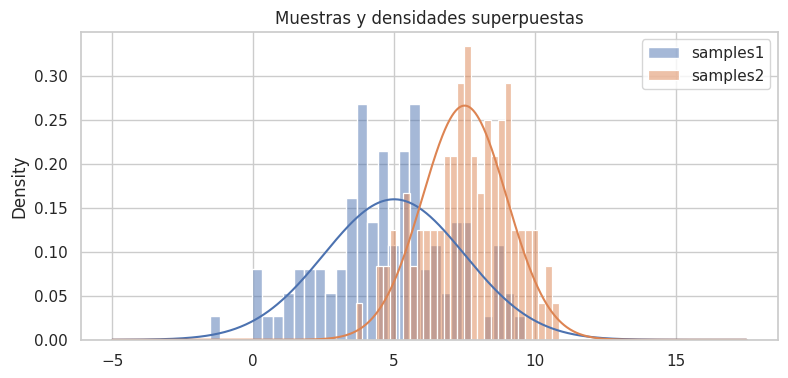

In [20]:

plt.figure(figsize=(9, 4))
sns.histplot(samples1, bins=30, color='C0', alpha=0.5, stat='density', label='samples1')
sns.histplot(samples2, bins=30, color='C1', alpha=0.5, stat='density', label='samples2')
plt.plot(x, pdf1, color='C0')
plt.plot(x, pdf2, color='C1')
plt.legend()
plt.title('Muestras y densidades superpuestas')
plt.show()

In [21]:
# 6) crear df_test con 50 muestras mezcladas 
n_test = 50
test1 = stats.norm(loc=mu1, scale=sigma1).rvs(size=n_test//2, random_state=11)
test2 = stats.norm(loc=mu2, scale=sigma2).rvs(size=n_test - n_test//2, random_state=13)
X_test = np.concatenate([test1, test2])[:, None]
Y_test = np.concatenate([np.zeros(len(test1)), np.ones(len(test2))])
df_test = pd.DataFrame({'X': X_test.ravel(), 'Y': Y_test.astype(int)})
df_test.head()

,X,Y
0,9.373637,0
1,4.284818,0
2,3.788587,0
3,-1.633296,0
4,4.979288,0


## 7) Ajuste de clasificadores y evaluación 

In [22]:
# preparar X/Y para sklearn
X_train = df_train[['X']].values
y_train = df_train['Y'].values
X_test = df_test[['X']].values
y_test = df_test['Y'].values

# Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(X_train, y_train)
print('DecisionTree valor de entrenamiento:', dt.score(X_train, y_train))
print('DecisionTree valor de prueba:', dt.score(X_test, y_test))

# SVM (lineal)
svm = SVC(kernel='linear', C=0.025, probability=False, random_state=0)
svm.fit(X_train, y_train)
print('SVC valor de entrenamiento:', svm.score(X_train, y_train))
print('SVC valor de prueba:', svm.score(X_test, y_test))

DecisionTree valor de entrenamiento: 0.815
DecisionTree valor de prueba: 0.74
SVC valor de entrenamiento: 0.78
SVC valor de prueba: 0.74


## 8) Ejemplo de GridSearchCV sobre DecisionTree 

In [23]:
param_grid = {'max_depth': [2,3,4,5], 'criterion': ['gini','entropy']}
cv_dt = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid=param_grid, cv=5)
cv_dt.fit(X_train, y_train)
print('Best params DecisionTree:', cv_dt.best_params_)
print('Best score CV:', cv_dt.best_score_)

Best params DecisionTree: {'criterion': 'gini', 'max_depth': 2}
Best score CV: 0.7850000000000001


## 9) Curvas de aprendizaje (ejemplo con regresión lineal)
A continuación se muestra una función simple para graficar curvas de aprendizaje con `learning_curve`.

## 10) Curvas de aprendizaje para distintos escenarios
Repite el experimento con los cuatro conjuntos de parámetros pedidos en el laboratorio y, para cada uno, genera las muestras, ajusta una regresión lineal y grafica su curva de aprendizaje.

Escenario 1: Learning Curve - n_train=30, mu1=7.5, mu2=10.0, sigma1=1.0, sigma2=1.0


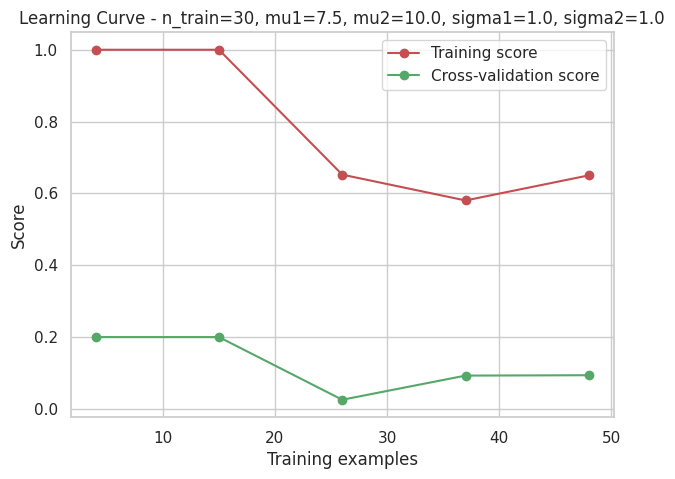

Escenario 2: Learning Curve - n_train=100, mu1=7.5, mu2=10.0, sigma1=1.0, sigma2=1.0


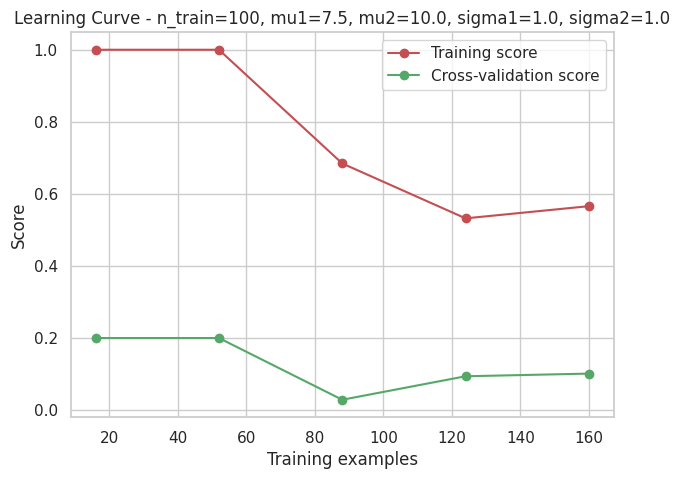

Escenario 3: Learning Curve - n_train=200, mu1=7.5, mu2=7.0, sigma1=2.0, sigma2=2.0


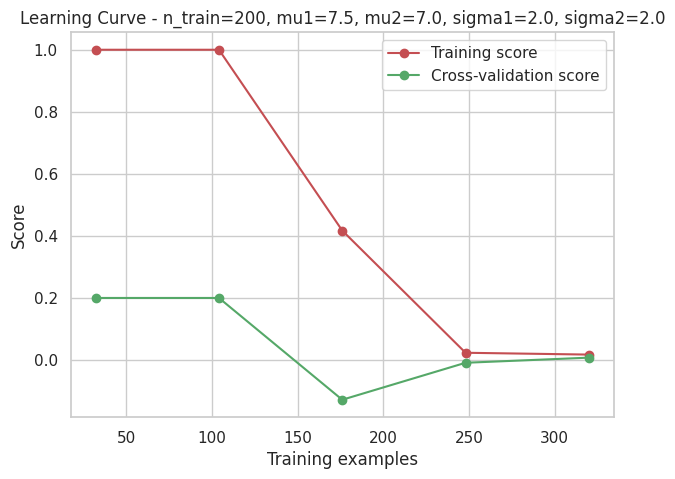

Escenario 4: Learning Curve - n_train=200, mu1=7.5, mu2=7.0, sigma1=0.5, sigma2=0.5


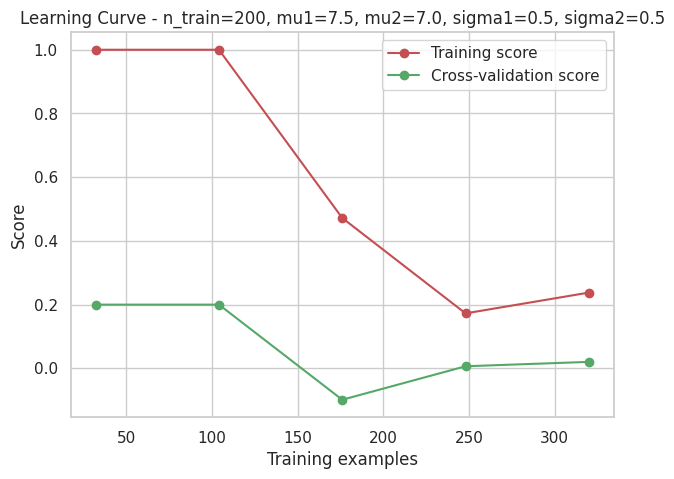

In [24]:
def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(7, 5))
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


def build_dataset(mu1, mu2, sigma1, sigma2, n_train, seed=42):
    rng_local = np.random.default_rng(seed)
    samples1 = stats.norm(loc=mu1, scale=sigma1).rvs(size=n_train, random_state=rng_local)
    samples2 = stats.norm(loc=mu2, scale=sigma2).rvs(size=n_train, random_state=rng_local)
    Xtr_ = np.concatenate([samples1, samples2])[:, None]
    ytr_ = np.concatenate([np.zeros(n_train), np.ones(n_train)])
    return Xtr_, ytr_


scenarios = [
    {'n_train': 30, 'mu1': 7.5, 'mu2': 10.0, 'sigma1': 1.0, 'sigma2': 1.0},
    {'n_train': 100, 'mu1': 7.5, 'mu2': 10.0, 'sigma1': 1.0, 'sigma2': 1.0},
    {'n_train': 200, 'mu1': 7.5, 'mu2': 7.0, 'sigma1': 2.0, 'sigma2': 2.0},
    {'n_train': 200, 'mu1': 7.5, 'mu2': 7.0, 'sigma1': 0.5, 'sigma2': 0.5},
]

regr = LinearRegression()

for idx, escenario in enumerate(scenarios, start=1):
    Xtr_, ytr_ = build_dataset(
        escenario['mu1'],
        escenario['mu2'],
        escenario['sigma1'],
        escenario['sigma2'],
        escenario['n_train'],
        seed=42 + idx,
    )
    title = (
        f"Learning Curve - n_train={escenario['n_train']}, "
        f"mu1={escenario['mu1']}, mu2={escenario['mu2']}, "
        f"sigma1={escenario['sigma1']}, sigma2={escenario['sigma2']}"
    )
    print(f"Escenario {idx}: {title}")
    plot_learning_curve(regr, title, Xtr_, ytr_, cv=5, n_jobs=1)